# Buổi 1: Làm quen Neural Network qua bài toán dự đoán giá nhà

Mục tiêu buổi đầu:
- Hiểu luồng làm việc cơ bản của Machine Learning.
- Chạy được một mô hình MLP đơn giản.
- Đọc được MAE/MSE và thử dự đoán mẫu mới.

Cách học: chạy lần lượt từ trên xuống, mỗi bước chỉ nắm 1 ý chính.

## Lộ trình 5 bước trong buổi học

1. Đọc dữ liệu.
2. Vẽ biểu đồ để nhìn xu hướng.
3. Chuẩn bị dữ liệu cho mô hình.
4. Huấn luyện MLP đơn giản.
5. Đánh giá và thử dự đoán mẫu mới.

## 1) Đọc dữ liệu và xem nhanh

In [1]:
# 1) Import cac thu vien can dung trong bai
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# 2) Tim duong dan file du lieu theo 2 truong hop thuong gap
DATA = Path("../data/sample_houses.csv")
if not DATA.exists():
    DATA = Path("data/sample_houses.csv")

# 3) Doc CSV vao DataFrame de xu ly bang pandas
df = pd.read_csv(DATA)

# 4) In thong tin tong quan va hien thi 5 dong dau
print("Rows:", len(df), "| Cols:", df.shape[1])
df.head()

Rows: 150 | Cols: 11


,id,city,district,area_m2,bedrooms,bathrooms,floors,building_type,year_built,price_million_vnd,price_per_m2_million_vnd
0,1,Ho Chi Minh City,Quan 9,144.1,3,1,5,townhouse,2022,8937.19,62.02
1,2,Ho Chi Minh City,Quan 7,133.9,4,3,5,house,2005,11187.61,83.55
2,3,Ha Noi,Dong Da,52.0,4,2,5,apartment,2009,3550.30,68.28
3,4,Ha Noi,Dong Da,146.9,3,2,3,townhouse,2024,12626.00,85.95
4,5,Ho Chi Minh City,Thu Duc,102.9,1,1,2,apartment,2017,7266.38,70.62


In [3]:
# Thong ke mo ta: giup nhin nhanh phan bo du lieu so va tan suat du lieu chu
df.describe(include="all")

,id,city,district,area_m2,bedrooms,bathrooms,floors,building_type,year_built,price_million_vnd,price_per_m2_million_vnd
count,150.000000,150,150,150.000000,150.000000,150.000000,150.00000,150,150.000000,150.000000,150.000000
unique,NaN,2,13,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,Ho Chi Minh City,Quan 9,NaN,NaN,NaN,NaN,apartment,NaN,NaN,NaN
freq,NaN,81,16,NaN,NaN,NaN,NaN,55,NaN,NaN,NaN
mean,75.500000,NaN,NaN,90.412667,2.466667,1.993333,3.00000,NaN,2011.593333,7024.636133,77.556467
std,43.445368,NaN,NaN,34.065482,1.103178,0.815098,1.42838,NaN,7.929299,3316.538992,22.204036
min,1.000000,NaN,NaN,31.300000,1.000000,1.000000,1.00000,NaN,2000.000000,1445.780000,42.380000
25%,38.250000,NaN,NaN,64.550000,2.000000,1.000000,2.00000,NaN,2003.250000,4622.417500,59.477500
50%,75.500000,NaN,NaN,89.750000,2.000000,2.000000,3.00000,NaN,2012.500000,6656.895000,72.155000
75%,112.750000,NaN,NaN,119.950000,3.000000,3.000000,4.00000,NaN,2019.000000,8924.085000,98.012500


## 2) Vẽ nhanh diện tích và giá

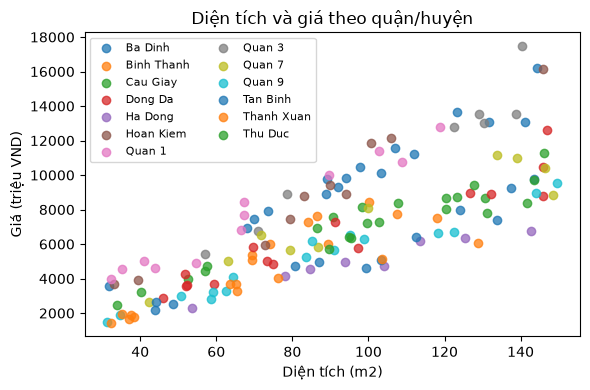

In [13]:
# Ve scatter plot de quan sat quan he giua dien tich va gia nha
plt.figure(figsize=(6, 4))

# Moi district la mot nhom diem de so sanh mat bang gia
for district, g in df.groupby("district"):
    plt.scatter(g["area_m2"], g["price_million_vnd"], label=district, alpha=0.75)

# Dat nhan truc va tieu de de doc do thi ro rang
plt.xlabel("Diện tích (m2)")
plt.ylabel("Giá (triệu VND)")
plt.legend(ncol=2, fontsize=8)
plt.title("Diện tích và giá theo quận/huyện")
plt.tight_layout()
plt.show()

## 3) Chuẩn bị dữ liệu cho mô hình

Dùng ít biến để dễ hiểu ngay buổi đầu:
- Biến số: diện tích, số phòng ngủ, số tầng
- Biến phân loại: quận/huyện

### Toán nền tảng dùng trong bài này

1) Chuẩn hóa dữ liệu (Standardization):

$$x' = \frac{x - \mu}{\sigma}$$

2) Một neuron đầy đủ (fully-connected):

$$z = \mathbf{w}^\top \mathbf{x} + b$$

3) Kích hoạt ReLU:

$$a = \max(0, z)$$

4) Hàm mất mát hồi quy:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

5) Ý tưởng cập nhật trọng số (gradient descent):

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

Trong đó:
- $\eta$ là learning rate (bước học).
- $L$ là loss (ở đây thường dùng MSE).

In [25]:
# Vi du tinh tay 1 neuron de thay dung nghia tung bien trong cong thuc
import numpy as np

# x: vector dau vao, w: trong so, b: bias, y_true: gia tri that
x = np.array([0.5, -1.0])
w = np.array([2.0, -3.0])
b = 0.1
y_true = 5.0

# Buoc 1: tinh z = w.x + b
z = w @ x + b

# Buoc 2: qua ham kich hoat ReLU => a = max(0, z)
a = max(0.0, z)

# Gia su day la dau ra cuoi cung cua mang
y_hat = a

# Tinh sai so tuyet doi va sai so binh phuong
abs_err = abs(y_true - y_hat)
sq_err = (y_true - y_hat) ** 2

print(f"z = {z:.2f}")
print(f"a = ReLU(z) = {a:.2f}")
print(f"|y - y_hat| = {abs_err:.2f}")
print(f"(y - y_hat)^2 = {sq_err:.2f}")

z = 4.10
a = ReLU(z) = 4.10
|y - y_hat| = 0.90
(y - y_hat)^2 = 0.81


In [19]:
# Chon cac cot so va cot phan loai cho bai toan du doan
num_cols = ["area_m2", "bedrooms", "bathrooms", "floors", "year_built"]
cat_cols = ["district", "building_type"]

# One-hot encoding bien phan loai, sau do ghep voi bien so
X = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, dtype=float)

# Target la gia nha (trieu VND)
y = df["price_million_vnd"].values

# Chia du lieu train/test de danh gia mo hinh cong bang
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# Chuan hoa dac trung dau vao de MLP hoc on dinh hon
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

# Chuan hoa target y de qua trinh toi uu de hoi tu hon
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Kiem tra kich thuoc du lieu va ten cot sau ma hoa
X_train.shape, X_test.shape, list(X.columns)

((120, 21),
 (30, 21),
 ['area_m2',
  'bedrooms',
  'bathrooms',
  'floors',
  'year_built',
  'district_Ba Dinh',
  'district_Binh Thanh',
  'district_Cau Giay',
  'district_Dong Da',
  'district_Ha Dong',
  'district_Hoan Kiem',
  'district_Quan 1',
  'district_Quan 3',
  'district_Quan 7',
  'district_Quan 9',
  'district_Tan Binh',
  'district_Thanh Xuan',
  'district_Thu Duc',
  'building_type_apartment',
  'building_type_house',
  'building_type_townhouse'])

## 4) Tạo mô hình MLP đơn giản

Mạng nhỏ cho buổi đầu: 1 hidden layer gồm 16 neuron.

Giải thích chi tiết về neuron:
- Mỗi neuron nhận toàn bộ đầu vào, rồi tính tổng có trọng số: z = w1x1 + w2x2 + ... + wkxk + b.
- Sau đó qua hàm kích hoạt ReLU: a = max(0, z).
- Một neuron học 1 góc nhìn nhỏ của dữ liệu. 16 neuron nghĩa là mô hình học 16 góc nhìn khác nhau.
- Đầu ra của 16 neuron sẽ được kết hợp để dự đoán giá nhà cuối cùng.

Vì sao chọn 16 cho buổi đầu:
- Đủ nhỏ để dễ hình dung và chạy nhanh.
- Đủ lớn để học quan hệ phi tuyến cơ bản.
- Tránh mô hình quá phức tạp khi sinh viên mới làm quen.

Số tham số cần học (để liên hệ toán):
- Gọi k là số đặc trưng đầu vào sau khi mã hóa.
- Tầng ẩn: k x 16 trọng số + 16 bias.
- Tầng ra: 16 x 1 trọng số + 1 bias.
- Tổng tham số: k x 16 + 33.

In [30]:
# Tao mo hinh MLP cho bai toan hoi quy
model = MLPRegressor(
    hidden_layer_sizes=(16,),   # 1 hidden layer, 16 neuron
    activation="relu",          # Ham kich hoat ReLU
    solver="adam",              # Bo toi uu Adam
    learning_rate_init=1e-3,    # Toc do hoc ban dau
    max_iter=800,               # So lan lap toi da
    early_stopping=True,        # Dung som neu khong cai thien tren validation
    random_state=42,            # Co dinh random de tai lap ket qua
    batch_size=16,              # So mau moi mini-batch
    )

# Hien thi cau hinh model de sinh vien doi chieu
model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16,)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",16
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",800
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'

## 5) Huấn luyện mô hình

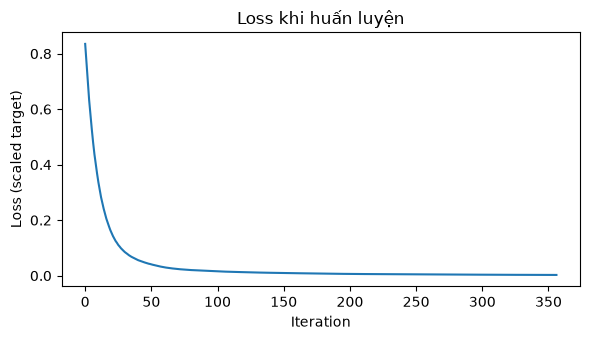

In [32]:
# Train model tren du lieu train da chuan hoa
model.fit(X_train, y_train_s)

# Ve duong loss theo iteration de xem model hoc ra sao
plt.figure(figsize=(6, 3.5))
plt.plot(model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss (scaled target)")
plt.title("Loss khi huấn luyện")
plt.tight_layout()
plt.show()

## 6) Đánh giá kết quả trên tập test

### Mẫu tính MAE/MSE từ vài dự đoán đầu

Bước này giúp sinh viên tự kiểm tra lại công thức bằng số thật từ mô hình.

In [33]:
# Du doan tren tap test (dang scale), sau do dua ve don vi goc
y_hat_s = model.predict(X_test).reshape(-1, 1)
y_hat = scaler_y.inverse_transform(y_hat_s).ravel()

# Tinh 2 chi so danh gia pho bien cho hoi quy
mae = mean_absolute_error(y_test, y_hat)
mse = mean_squared_error(y_test, y_hat)
print(f"MAE = {mae:.1f} triệu VND")
print(f"MSE = {mse:.1f}")

# Tao bang so sanh gia that va gia du doan de xem tung mau
so_sanh = pd.DataFrame(
    {"gia_that": y_test, "gia_du_doan": y_hat.round(0)}
)
so_sanh.head(10)

MAE = 1258.9 triệu VND
MSE = 3153981.7


,gia_that,gia_du_doan
0,8422.91,7672.0
1,6912.11,6727.0
2,6741.88,6011.0
3,13680.16,10991.0
4,3294.92,2944.0
5,6740.97,6034.0
6,8810.15,10008.0
7,3663.36,4084.0
8,13562.97,11538.0
9,5034.10,4571.0


In [26]:
# Tinh tay MAE MSE tren 5 mau dau de doi chieu voi cong thuc ly thuyet
n = 5
y_true_5 = so_sanh["gia_that"].values[:n]
y_pred_5 = so_sanh["gia_du_doan"].values[:n]

# Tinh sai so tuyet doi va sai so binh phuong cho tung mau
abs_err_5 = np.abs(y_true_5 - y_pred_5)
sq_err_5 = (y_true_5 - y_pred_5) ** 2

# Ghep vao bang de sinh vien de kiem tra tung phep tinh
bang_5 = pd.DataFrame(
    {
        "y_true": y_true_5,
        "y_pred": y_pred_5,
        "|error|": abs_err_5,
        "error^2": sq_err_5,
    }
)

# MAE MSE cua 5 mau dau
print("MAE(5 mau) =", round(abs_err_5.mean(), 2))
print("MSE(5 mau) =", round(sq_err_5.mean(), 2))
bang_5

MAE(5 mau) = 2364.08
MSE(5 mau) = 6772149.19


,y_true,y_pred,|error|,error^2
0,8422.91,9747.0,1324.09,1.753214e+06
1,6912.11,4594.0,2318.11,5.373634e+06
2,6741.88,9563.0,2821.12,7.958718e+06
3,13680.16,9514.0,4166.16,1.735689e+07
4,3294.92,2104.0,1190.92,1.418290e+06


## 7) Thử dự đoán một căn nhà mới

Đổi số rồi chạy lại để thấy mô hình phản ứng.

In [23]:
# Tao 1 mau nha moi de thu du doan
moi = {
    "district": "Thu Duc",
    "building_type": "apartment",
    "area_m2": 60,
    "bedrooms": 2,
    "bathrooms": 2,
    "floors": 2,
    "year_built": 2018,
}

# Dua ve DataFrame va one-hot encoding giong du lieu train
hang = pd.DataFrame([moi])
hang = pd.get_dummies(hang, columns=cat_cols, dtype=float)

# Bo sung cot thieu de trung dung schema voi X luc train
for cot in X.columns:
    if cot not in hang.columns:
        hang[cot] = 0.0
hang = hang[X.columns]

# Chuan hoa x moi, du doan, roi inverse transform ve trieu VND
xs = scaler_x.transform(hang.values)
gia = scaler_y.inverse_transform(model.predict(xs).reshape(-1, 1))[0, 0]

print(f"Dự đoán: {gia:.0f} triệu VND (~ {gia/1000:.2f} tỷ)")

Dự đoán: 3313 triệu VND (~ 3.31 tỷ)


## Câu hỏi cuối buổi

1. Khi diện tích tăng, giá dự đoán thường tăng hay giảm?
2. MAE khoảng bao nhiêu triệu VND?
3. Khi đổi quận/huyện, giá thay đổi thế nào?
4. Thử đổi hidden layer `(16,)` thành `(32,)`, kết quả có khá hơn không?